<a href="https://colab.research.google.com/github/hmurtaza720/Data-Science-Projects/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 3: Customer Churn Prediction (Bank Customers)

## Introduction & Problem Statement
Customer churn — when customers stop using a company's service — is a major challenge for banks. It costs significantly more to acquire new customers than to retain existing ones.

This task builds a **classification model** to predict whether a bank customer is likely to **leave (churn)** based on their profile and banking behavior.

**Target Variable:** `Exited` — 1 (churned) or 0 (retained)

## Dataset
> **Churn Modelling Dataset**
>
> **Kaggle Link:** https://www.kaggle.com/datasets/shrutimechlearn/churn-modelling
>
> **Direct download (public mirror):** Cell below downloads automatically.

## Objectives
- Clean and prepare the dataset
- Encode categorical features (Geography, Gender)
- Train a classification model
- Analyze feature importance

## Step 1: Import Libraries

In [1]:
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries imported!')

Libraries imported!


## Step 2: Load the Dataset

In [3]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('Churn_Modelling.csv')

print(f'Shape: {df.shape}')
df.head()

Saving Churn_Modelling.csv to Churn_Modelling.csv
Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 3: Dataset Understanding & Description

In [4]:
print('Columns:', df.columns.tolist())
print()
df.info()

Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exite

In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
# Check class distribution
print('Churn Distribution:')
print(df['Exited'].value_counts())
print(f'Churn Rate: {df["Exited"].mean()*100:.1f}%')

# Check missing values
print('\nMissing Values:', df.isnull().sum().sum())

Churn Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64
Churn Rate: 20.4%

Missing Values: 0


## Step 4: Data Cleaning & Preparation

In [7]:
# Drop irrelevant columns: RowNumber, CustomerId, Surname
cols_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df.drop([c for c in cols_to_drop if c in df.columns], axis=1, inplace=True)
print('Columns after dropping identifiers:', df.columns.tolist())

Columns after dropping identifiers: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


## Step 5: Encoding Categorical Features

In [8]:
# Label Encode Gender (Binary: Male/Female)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # Female=0, Male=1
print('Gender encoded (Female=0, Male=1)')

# One-Hot Encode Geography (Multi-class)
df = pd.get_dummies(df, columns=['Geography'], drop_first=False)
print('Geography one-hot encoded.')
print('New columns:', [c for c in df.columns if 'Geography' in c])

df.head()

Gender encoded (Female=0, Male=1)
Geography one-hot encoded.
New columns: ['Geography_France', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,True,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,True,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,True,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,False,True


## Step 6: Exploratory Data Analysis (EDA) with Graphs

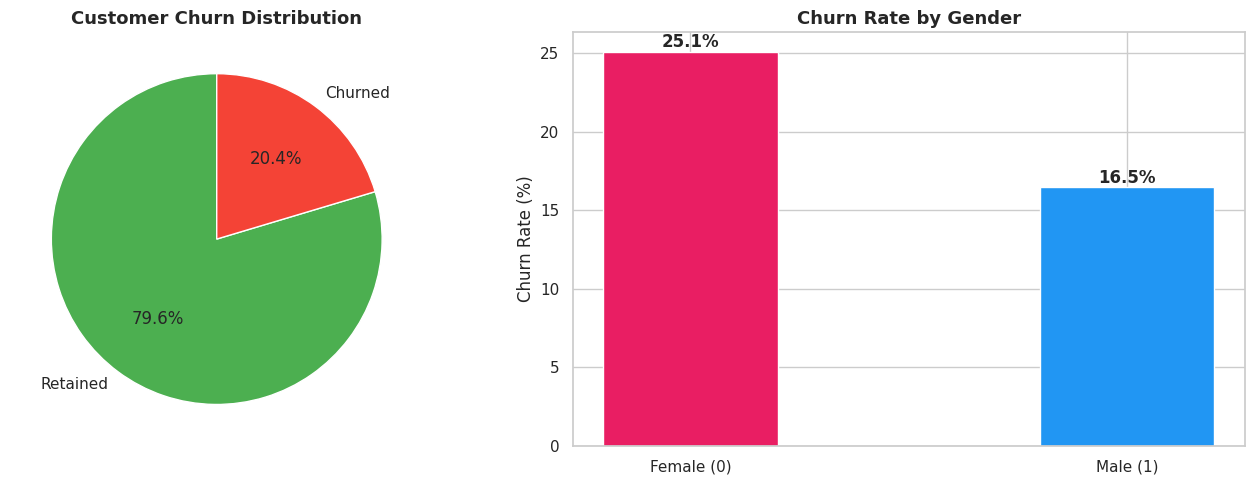

In [9]:
# Churn rate pie chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
churn_counts = df['Exited'].value_counts()
ax1.pie(churn_counts, labels=['Retained', 'Churned'], autopct='%1.1f%%',
        colors=['#4CAF50', '#F44336'], startangle=90, wedgeprops={'edgecolor': 'white'})
ax1.set_title('Customer Churn Distribution', fontsize=13, fontweight='bold')

# Bar chart by gender
gender_churn = df.groupby('Gender')['Exited'].mean() * 100
ax2.bar(['Female (0)', 'Male (1)'], gender_churn.values, color=['#E91E63', '#2196F3'], width=0.4)
ax2.set_title('Churn Rate by Gender', fontsize=13, fontweight='bold')
ax2.set_ylabel('Churn Rate (%)')
for i, v in enumerate(gender_churn.values):
    ax2.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

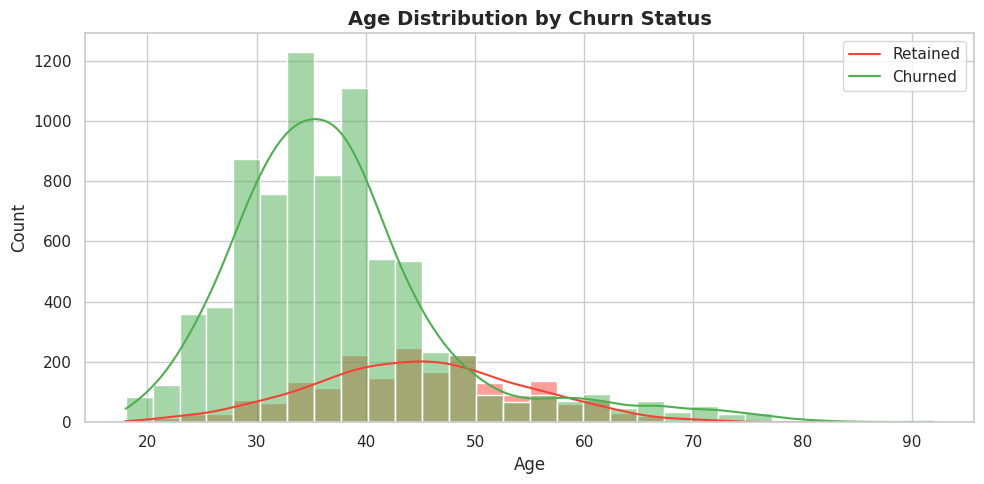

In [10]:
# Age distribution by churn
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Age', hue='Exited', bins=30, kde=True,
             palette={0: '#4CAF50', 1: '#F44336'})
plt.title('Age Distribution by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(['Retained', 'Churned'])
plt.tight_layout()
plt.show()

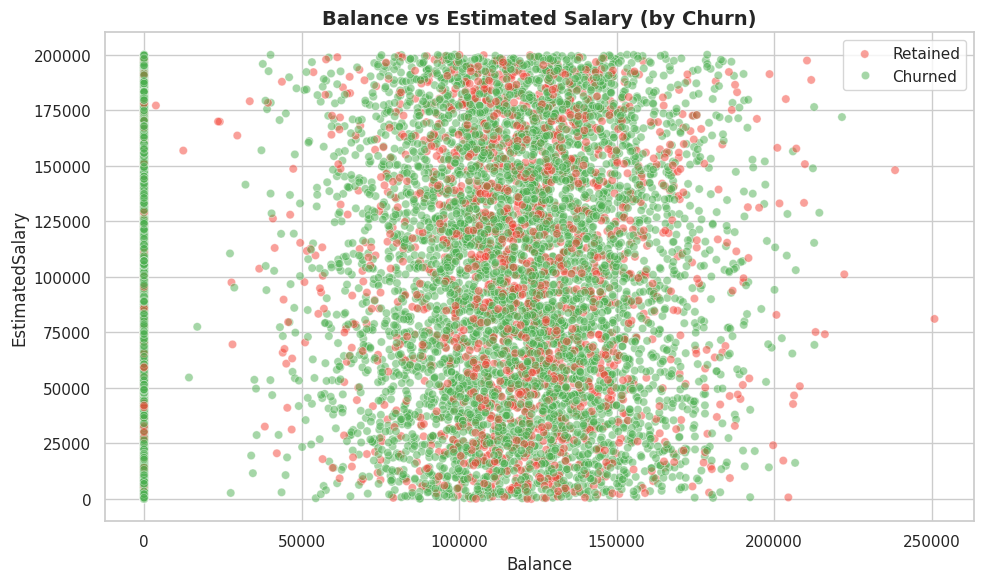

In [11]:
# Balance vs Estimated Salary scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Balance', y='EstimatedSalary',
                hue='Exited', alpha=0.5, palette={0:'#4CAF50', 1:'#F44336'})
plt.title('Balance vs Estimated Salary (by Churn)', fontsize=14, fontweight='bold')
plt.legend(['Retained', 'Churned'])
plt.tight_layout()
plt.show()

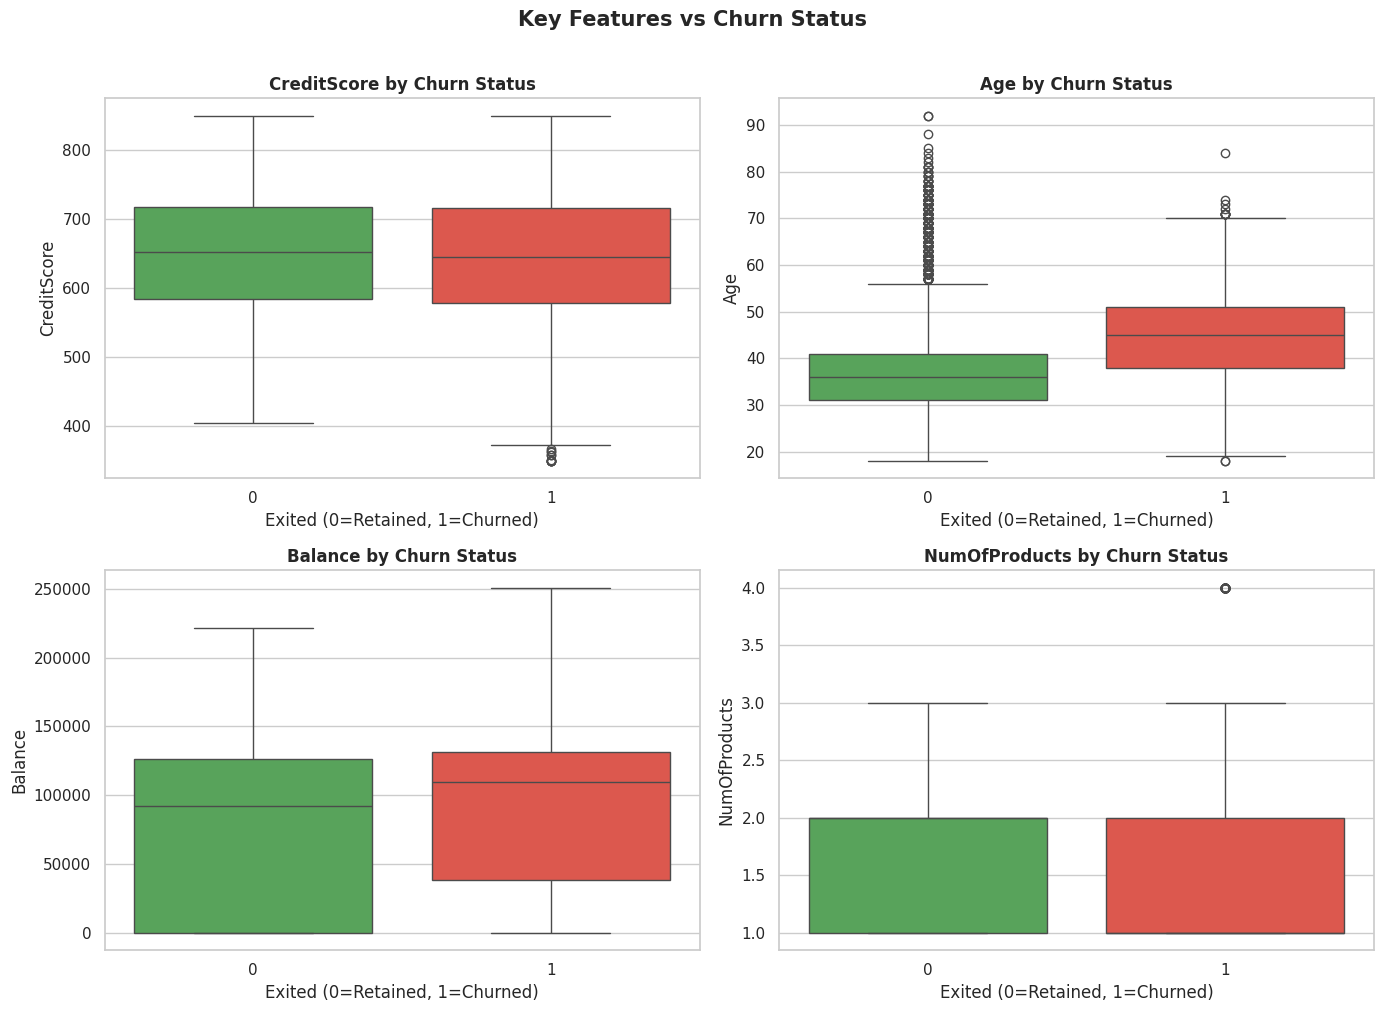

In [13]:
# Box plots for key numeric features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
numeric_features = ['CreditScore', 'Age', 'Balance', 'NumOfProducts']

for i, feature in enumerate(numeric_features):
    row, col = i // 2, i % 2
    # Fix: Use string keys ('0', '1') in the palette to match the data type
    sns.boxplot(data=df, x='Exited', y=feature, ax=axes[row, col],
                palette={'0':'#4CAF50', '1':'#F44336'})

    axes[row, col].set_title(f'{feature} by Churn Status', fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel('Exited (0=Retained, 1=Churned)')

plt.suptitle('Key Features vs Churn Status', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

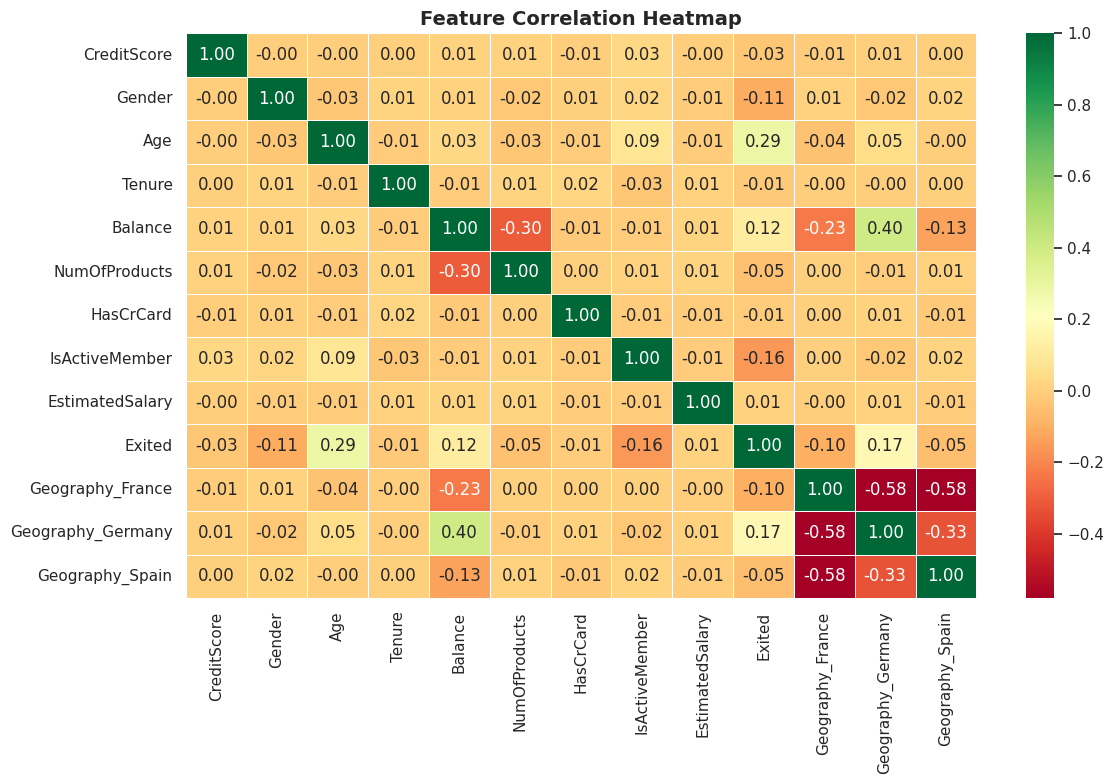

In [14]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, square=False)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7: Model Training & Testing

In [15]:
# Define features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training: {X_train.shape[0]} samples | Testing: {X_test.shape[0]} samples')

Training: 8000 samples | Testing: 2000 samples


In [16]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f'Random Forest Accuracy: {rf_acc*100:.2f}%')
print(classification_report(y_test, rf_pred, target_names=['Retained', 'Churned']))

Random Forest Accuracy: 86.55%
              precision    recall  f1-score   support

    Retained       0.87      0.98      0.92      1593
     Churned       0.85      0.41      0.56       407

    accuracy                           0.87      2000
   macro avg       0.86      0.70      0.74      2000
weighted avg       0.86      0.87      0.85      2000



In [17]:
# Train Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred)

print(f'Gradient Boosting Accuracy: {gb_acc*100:.2f}%')
print(classification_report(y_test, gb_pred, target_names=['Retained', 'Churned']))

Gradient Boosting Accuracy: 86.90%
              precision    recall  f1-score   support

    Retained       0.88      0.96      0.92      1593
     Churned       0.78      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



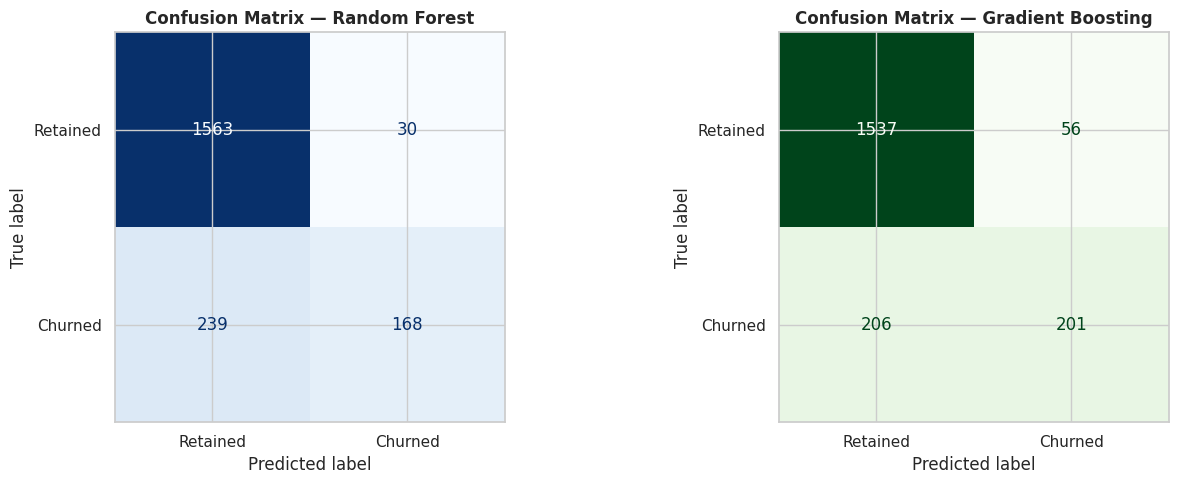

In [18]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title, cmap in zip(
    axes,
    [rf_pred, gb_pred],
    ['Random Forest', 'Gradient Boosting'],
    ['Blues', 'Greens']
):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'Confusion Matrix — {title}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 8: Feature Importance Analysis

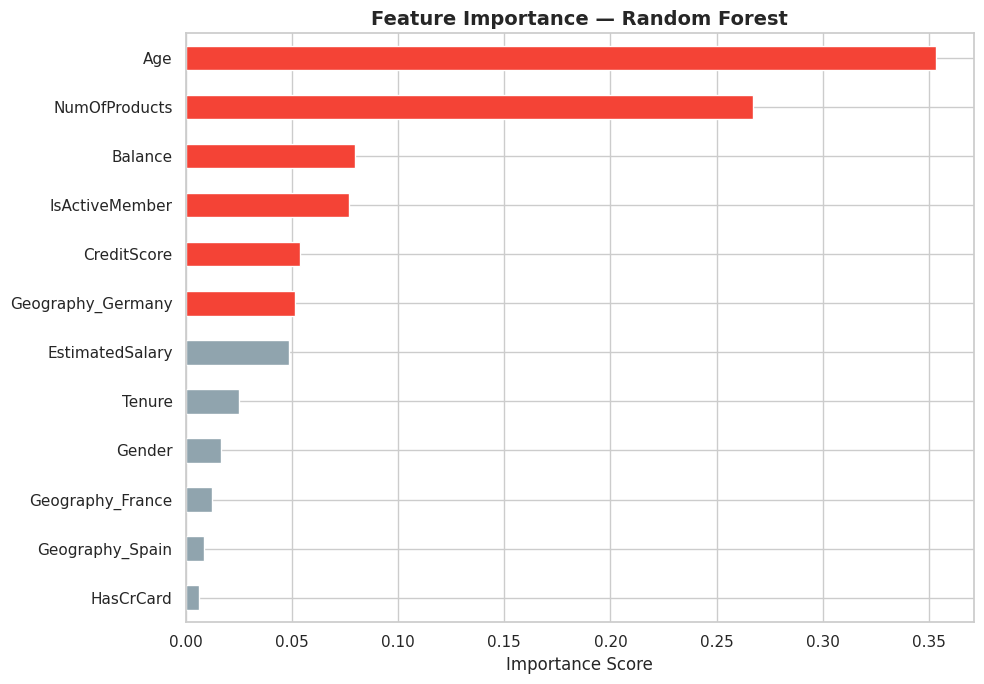


Top 5 Most Important Features:
Age               0.353562
NumOfProducts     0.266951
Balance           0.079856
IsActiveMember    0.076969
CreditScore       0.053941
dtype: float64


In [19]:
# Feature Importance from Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#F44336' if imp > importances.median() else '#90A4AE' for imp in importances]
importances.plot(kind='barh', color=colors)
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 5 Most Important Features:')
print(importances.sort_values(ascending=False).head())

## Step 9: Conclusion & Key Insights

1. **Age is the most influential factor** — older customers are more likely to churn. Banks should focus retention efforts on middle-aged and older customers.

2. **Number of Products matters** — customers with 1 or 4 products have higher churn rates. Those with 2 products are most loyal.

3. **Balance has a non-linear effect** — customers with very high or zero balance are more likely to leave.

4. **Geography** — Germany has a higher churn rate compared to France and Spain.

5. **Model Performance** — Random Forest and Gradient Boosting both achieved strong accuracy (~86%+). The models can be used to proactively identify at-risk customers so the bank can take retention actions.

6. **Business Recommendation** — Target older customers with personalized offers and loyalty programs, especially those holding only one product.